In [10]:
### your own paths here!
import sys
sys.path.append('/home/maclean/code')
sys.path.append('/home/maclean/code/hidfmux/')

import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import glob
import os
import pickle
import scipy.interpolate as interpolate
import scipy.signal as signal
import scipy.special
import copy

import hidfmux.core.resources.hardware_models as hardware
import hidfmux.core.utils.transferfunctions as transferfunctions
import hidfmux.core.utils.user_config as config
import hidfmux.plots_and_processing.iq_rotations as iq_rotations
import hidfmux.analysis.noise_processing as noise_processing
import hidfmux.analysis.fit_resonances as fit_resonances
import hidfmux.wafer_testing.common_tasks as tasks


from mr_complex_resonator import MR_complex_resonator as MR_complex_resonator
from mr_lekid import MR_LEKID as MR_LEKID
import utils



%matplotlib inline

mpl.style.use('default')
plt.rcParams.update({'xtick.labelsize' : '18'})
plt.rcParams.update({'ytick.labelsize' : '18'})
plt.rcParams.update({'legend.fontsize' : '13'})
plt.rcParams.update({'font.size' : '18'})
plt.rcParams.update({'axes.formatter.useoffset' : 'False'})
plt.rcParams['axes.grid'] = True


# convenience functions
def to_dbm(W):
    return 10*np.log10(W*1e3)

def to_W(dbm):
    return 10**(dbm/10.) * 1e-3

# if you have alredy created an analog chain class for a given setup:
import hidfmux.core.resources.analog_chains.slim_deployment_2024 as slim_ac


## set up an example analog hardware chain

Note on "Vin": mr_resonator's circuit model considers the point "Vin" to be BEFORE the last attenuator

It is also common to compute the power "at" the resonators, eg the total power available to the parallel resonators || LNA network. This is the thing usually quoted when talking about readout power supplied to the resonators, but it's much less useful for circuit model computations so we include both.

In [3]:
# input cables
warm_cables_in = hardware.SMA_cables(length_m=4)

# extra input attenuator
atten300K_input = hardware.Attenuator(-10, 300)

# cryocables in
cryo_cables_input = hardware.SMA_CuNi_cryo(length_m=1.5, temperature=4)

# cryo attenuators input
atten_4K = hardware.Attenuator(-20, 4)
atten_still = hardware.Attenuator(-10, 1)
atten_MXC = hardware.Attenuator(-10, 0.02)


# return amplifiers etc
lna = hardware.CryoElec_LNA()
wa1 = hardware.ZX60_3018Gplus()
wa2 = hardware.ZX60_3018Gplus()
warm_cables_output = hardware.SMA_cables(length_m=4)
cryo_cables_output = hardware.SMA_CuNi_cryo(length_m=1.5, temperature=4)
atten300K_output = hardware.Attenuator(-7, 300)


carrier_freq = 1.1e9
input_chain_to_Vin = [warm_cables_in, atten300K_input, cryo_cables_input, atten_4K, atten_still]
input_chain_total = np.append(input_chain_to_Vin, atten_MXC)
input_gain_to_Vin = np.sum([component.gain(carrier_freq) for component in input_chain_to_Vin])
input_gain_total = np.sum([component.gain(carrier_freq) for component in input_chain_total])
print('input gain to Vin:', input_gain_to_Vin)
print('input gain total:', input_gain_total)

# output
output_chain = [lna, wa1, wa2, warm_cables_output, cryo_cables_output, atten300K_output]
output_gain = np.sum([component.gain(carrier_freq) for component in output_chain])
print('output gain:', output_gain)


dacunits = 0.005 # for example
dbm_dac = transferfunctions.convert_dacunits_to_dbm(carrier_freq, dacunits)
dbm_at_Vin = dbm_dac + input_gain_to_Vin
dbm_at_Pg = dbm_dac + input_gain_total

carrier_amp_Vin = transferfunctions.convert_dbm_to_volts(dbm_at_Vin)
print('carrier V at Vin:', carrier_amp_Vin)


input gain to Vin: -48.662549999999996
input gain total: -58.662549999999996
output gain: 58.60623306878307
carrier V at Vin: 5.1980745564692815e-06


## resonator parameters for 50nm and 30nm aluminum

based on discussions between Adam A and Maclean R circa March 2026

In [4]:
###################
# params for 50nm #
###################

# res model values
C = 1.3e-12 # tuned to match the measured resonant frequencies
Cc = 6e-15 # tuned to match the measured Qc

Popt = 1e-18 # this is very dark; adjust as is proper
R_spoiler = 1e-4 ## simple excess loss mechanism -- increase this value until Qi matches measured resonators

width = 2e-6
volume = 135e-18
thickness = 50e-9
length = volume / (thickness * width)
print('length: %.2e'%(length))

T_base = 0.12

alpha_k = 0.05 # from Adam's measurements
Lg_50nm = 4e-9 # using alpha_k = 0.05, and using a VERY dark environment to forecast Lg from Lk 

res_params_50nm = dict(fix_Lg=Lg_50nm, material='Al_SLIM_50nm', C=C, Cc=Cc, R_spoiler=R_spoiler,
                  length=length, width=width, thickness=thickness, T=T_base,
                  Vin=carrier_amp_Vin, input_atten_dB=atten_MXC.gain(1.1e9), Popt=Popt)

res = MR_complex_resonator(**res_params_50nm)

Qr, Qi, Qc = res.lekid.compute_Q_values()
fr0 = res.lekid.compute_fr()
print('50nm:')
print('computed: model: fr: %.3f MHz, Qr: %.3e, Qi: %.3e, Qc: %.3e'%(fr0*1e-6, Qr, Qi, Qc))

Qr, Qi, Qc = res.lekid.fit_for_Q_values()
fr0 = res.lekid.compute_fr()
print('fitted: model: fr: %.3f MHz, Qr: %.3e, Qi: %.3e, Qc: %.3e'%(fr0*1e-6, Qr, Qi, Qc))



###################
# params for 30nm #
###################

Lg_50nm = 4e-9 # using alpha_k = 0.05, and using a VERY dark environment to forecast Lg from Lk 
C = 0.8e-12 # tuned to match the resonant frequency and Qc of the 50nm version
Cc = 5e-15 # tuned to match the resonant frequency and Qc of the 50nm version
Popt = 1e-18
R_spoiler = 1e-4 # I guess we should assume that loss is the same between the two thicknesses...?
# that is probably reasonable if it's coming from the dielctric?

width = 2e-6
thickness = 30e-9
length = 1.35e-03
volume = length * thickness * width
print('length: %.2e'%(length), 'volume:', volume)

fix_Lg = Lg_50nm * (5./3.)

res_params_30nm = dict(fix_Lg=fix_Lg, material='Al_SLIM_30nm', C=C, Cc=Cc, R_spoiler=R_spoiler,
                  length=length, width=width, thickness=thickness, 
                  Vin=carrier_amp_Vin, input_atten_dB=-atten_MXC.gain(1.1e9), Popt=Popt)


res = MR_complex_resonator(**res_params_30nm)

Qr, Qi, Qc = res.lekid.compute_Q_values()
fr0 = res.lekid.compute_fr()
print('30nm:')
print('computed: model: fr: %.3f MHz, Qr: %.3e, Qi: %.3e, Qc: %.3e'%(fr0*1e-6, Qr, Qi, Qc))

Qr, Qi, Qc = res.lekid.fit_for_Q_values()
fr0 = res.lekid.compute_fr()
print('fitted: model: fr: %.3f MHz, Qr: %.3e, Qi: %.3e, Qc: %.3e'%(fr0*1e-6, Qr, Qi, Qc))


length: 1.35e-03
50nm:
computed: model: fr: 2146.819 MHz, Qr: 7.754e+04, Qi: 2.811e+05, Qc: 1.071e+05
fitted: model: fr: 2146.819 MHz, Qr: 8.386e+04, Qi: 2.811e+05, Qc: 1.195e+05
length: 1.35e-03 volume: 8.099999999999998e-17
30nm:
computed: model: fr: 2092.240 MHz, Qr: 8.029e+04, Qi: 4.576e+05, Qc: 9.737e+04
fitted: model: fr: 2092.240 MHz, Qr: 8.794e+04, Qi: 4.576e+05, Qc: 1.089e+05


## some simple comparison plots between the two resonator designs

54579197.922736645
-905421695.5428401
-1816141541.4909897


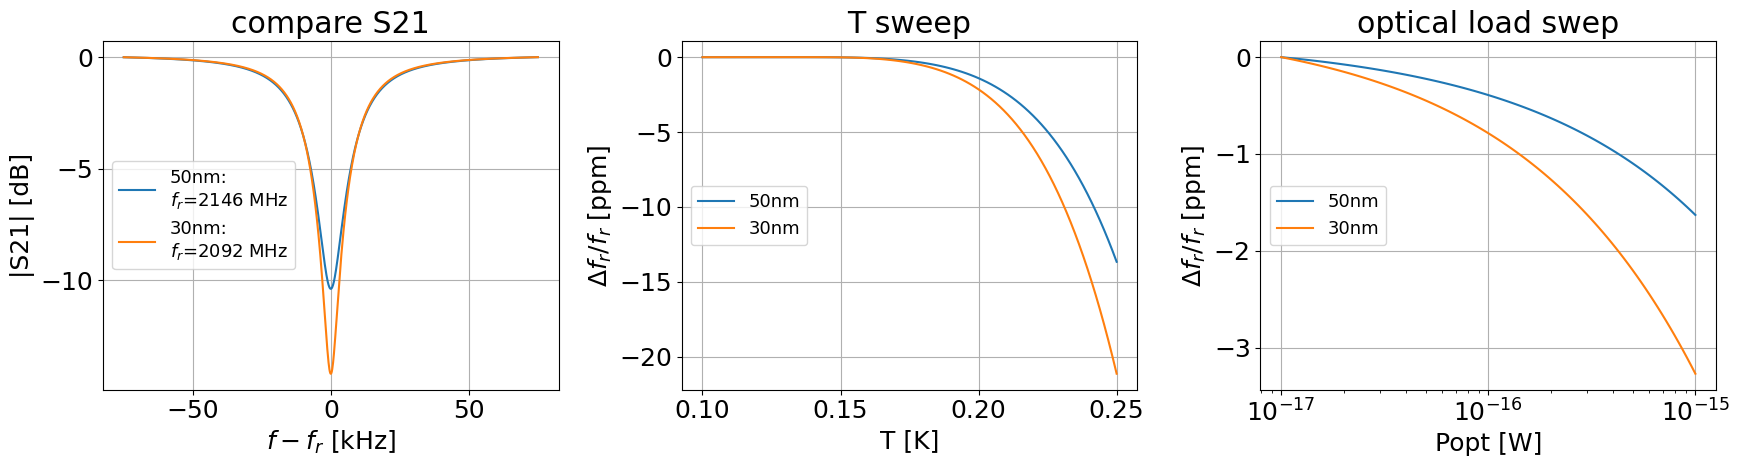

In [5]:



nplots = 3
fig = plt.figure(figsize=(nplots*6, 5))
axarr = []
for x in range(nplots):
    ax = fig.add_subplot(1, nplots, x+1)
    axarr.append(ax)

### compare resonator shapes
T = 0.1
Popt = 1e-18
res_params_50nm['T'] = T
res_params_50nm['Popt'] = Popt
res = MR_complex_resonator(**res_params_50nm)
fr = res.lekid.compute_fr()
span = 75e3
frange = np.linspace(fr-span, fr+span, 1000)
Vout = res.lekid.compute_Vout(frange)
mag_db = 20*np.log10(abs(Vout)/abs(Vout[-1]))
axarr[0].plot(1e-3*(frange-fr), mag_db, label='50nm:\n$f_r$=%d MHz'%(1e-6*fr))

res_params_30nm['T'] = T
res_params_30nm['Popt'] = Popt
res = MR_complex_resonator(**res_params_30nm)
fr = res.lekid.compute_fr()
frange = np.linspace(fr-span, fr+span, 1000)
Vout = res.lekid.compute_Vout(frange)
mag_db = 20*np.log10(abs(Vout)/abs(Vout[-1]))
axarr[0].plot(1e-3*(frange-fr), mag_db, label='30nm:\n$f_r$=%d MHz'%(1e-6*fr))

# temperature responsivity
delta_T = 0.001
res_params_50nm['T'] = T_base+delta_T
res_warm = MR_complex_resonator(**res_params_50nm)
delta_fr = res_warm.lekid.compute_fr() - res.lekid.compute_fr()
print(delta_fr)

Trange = np.linspace(0.1, 0.25, 100)
frs = []
for T in Trange:
    res_params_50nm['T'] = T
    res_warm = MR_complex_resonator(**res_params_50nm)
    frs.append(res_warm.lekid.compute_fr())
    
axarr[1].plot(Trange, 1e6*(frs-frs[0])/frs[0], label='50nm')


frs = []
for T in Trange:
    res_params_30nm['T'] = T
    res_warm = MR_complex_resonator(**res_params_30nm)
    frs.append(res_warm.lekid.compute_fr())
    
axarr[1].plot(Trange, 1e6*(frs-frs[0])/frs[0], label='30nm')

res_params_50nm['T'] = T_base
res_params_30nm['T'] = T_base

## Popt responsivity
# first just estimate a numerical responsivity at some representative loading, for NEP purposes
delta_P = 1e-18
Popt = 1e-15
res_params_50nm['Popt'] = Popt
res = MR_complex_resonator(**res_params_50nm)
res_params_50nm['Popt'] = Popt + delta_P
res_warm = MR_complex_resonator(**res_params_50nm)
dfr_over_fr_dPopt_50nm = ((res_warm.lekid.compute_fr() - res.lekid.compute_fr())/res.lekid.compute_fr()) / delta_P
print(dfr_over_fr_dPopt_50nm)

res_params_30nm['Popt'] = Popt
res = MR_complex_resonator(**res_params_30nm)
res_params_30nm['Popt'] = Popt + delta_P
res_warm = MR_complex_resonator(**res_params_30nm)
dfr_over_fr_dPopt_30nm = ((res_warm.lekid.compute_fr() - res.lekid.compute_fr())/res.lekid.compute_fr()) / delta_P
print(dfr_over_fr_dPopt_30nm)

# sweep Popt
Prange = np.logspace(-17, -15, 100)
frs = []
for Popt in Prange:
    res_params_50nm['Popt'] = Popt
    res = MR_complex_resonator(**res_params_50nm)
    frs.append(res.lekid.compute_fr())
    
axarr[2].plot(Prange, 1e6*(frs-frs[0])/frs[0], label='50nm')

frs = []
for Popt in Prange:
    res_params_30nm['Popt'] = Popt
    res = MR_complex_resonator(**res_params_30nm)
    frs.append(res.lekid.compute_fr())
    
axarr[2].plot(Prange, 1e6*(frs-frs[0])/frs[0], label='30nm')

axarr[0].set_ylabel('|S21| [dB]')
axarr[0].set_xlabel('$f - f_r$ [kHz]')
axarr[0].set_title('compare S21')
axarr[1].set_ylabel('$\\Delta f_r/f_r$ [ppm]')
axarr[1].set_xlabel('T [K]')
axarr[1].set_title('T sweep')
axarr[2].set_ylabel('$\\Delta f_r/f_r$ [ppm]')
axarr[2].set_xlabel('Popt [W]')
axarr[2].set_xscale('log')
axarr[2].set_title('optical load swep')

for x in axarr:
    x.legend(loc='center left')
fig.tight_layout()

## estimate NEP

In [13]:
def compute_NEP_quantities(res_params=res_params_50nm, Prange=np.logspace(-16, -12, 50), 
                           eta_opt=0.05, n_star=0, T=0.15,
                           nu_opt=180e9, Tn_LNA=6, ymin=2e-19, ymax=3e-16, ax_title=''):
    kb = 1.38e-23

    SLIM_Popt = 75e-15
    SLIM_photon_NEP = 7e-18

    dPopt = 1e-21

    Pfactor = 1e15 # for axis scaling
    skip = 4

    nplots = 1
    fig = plt.figure(figsize=(nplots*7, 6))
    axarr = []
    for x in range(nplots):
        ax = fig.add_subplot(1, nplots, x+1)
        axarr.append(ax)


    axarr[0].set_title(ax_title)
    working_res_params = copy.deepcopy(res_params)
    working_res_params['nstar'] = n_star
    working_res_params['opt_eff'] = eta_opt
    working_res_params['T'] = T
    working_res_params_dPopt = copy.deepcopy(working_res_params)

    res = MR_complex_resonator(**working_res_params)

    Qr, Qi, Qc = res.lekid.compute_Q_values()
    fr0 = res.lekid.compute_fr()
    print('computed: model: fr: %.3f MHz, Qr: %.3e, Qi: %.3e, Qc: %.3e'%(fr0*1e-6, Qr, Qi, Qc))

    # get the conversion factor between Sx and SN (for the LNA)
    # note for simplicity I'm using delta0 everywhere but it should actually be DeltaT
    ## it does not make much difference at low T
    zeta = res.zeta(f=res.lekid.compute_fr(), T=res.T)
    res_S2 = 1 + np.sqrt(2 * res.Delta0 / (np.pi * kb * res.T)) * np.exp(-zeta) * scipy.special.iv(0, zeta)
    model_Sx_factor = res.alpha_k * res_S2 / (4 * res.Delta0 * res.VL_um3 * res.N0)
    # such that Sn = Sx / ((1/VL)**2 * (model_Sx_factor)**2)


    NEP_total, NEP_gr, NEP_r, NEP_r_rt2 = [], [], [], []
    NEP_photon = []
    NEP_gr_classic = []
    NEP_g_th_only, NEP_gr_th_only = [], []

    NEP_r_direct = []
    NEP_r_th_only = []

    NEP_g_opt = []
    NEP_LNA = []
    for Popt in Prange:
        working_res_params['Popt'] = Popt
        res = MR_complex_resonator(**working_res_params)
        Qr, Qi, Qc = res.lekid.compute_Q_values()
        Sx_LNA = 4*kb*Tn_LNA*res.Z0 * (Qc**2 / (4 * Qr**4 * res.Vin**2))
        SN_LNA = Sx_LNA / ((model_Sx_factor)**2)
        Sn_LNA = SN_LNA / res.VL_um3**2
#         print(Sx_LNA)

        nqp = res.calc_nqp()
        photon_dPopt = res.est_photon_noise(nu=nu_opt) 

        working_res_params_dPopt['Popt'] = Popt + dPopt
        dres = MR_complex_resonator(**working_res_params_dPopt)
        nqp_loaded = dres.calc_nqp()
        dnqp_by_dPopt = (nqp_loaded - nqp) / dPopt

        NEP_LNA.append(np.sqrt(Sn_LNA) / dnqp_by_dPopt)

        frange = np.logspace(-2, 5.2, 25)
        frange, psd_total = res.calc_gr_PSD_thermal_optical(frange=frange, nu_opt=nu_opt)
        frange, gr_psd_classic = res.calc_gr_PSD(frange=frange)
        frange, rec_psd = res.calc_recombination_PSD(frange=frange)
        frange, g_opt_psd = res.calc_optical_generation_PSD(frange=frange, nu_opt=nu_opt)

        NEP_total.append(np.sqrt(psd_total[0] / res.VL_um3**2) / dnqp_by_dPopt)
        NEP_gr_classic.append(np.sqrt((gr_psd_classic[0] / res.VL_um3**2)) / dnqp_by_dPopt)
        NEP_r_direct.append(np.sqrt((rec_psd[0] / res.VL_um3**2)) / dnqp_by_dPopt)

        frange, gr_psd_th = res.calc_gr_PSD(frange=frange, Popt=0)
        NEP_gr_th_only.append( np.sqrt(gr_psd_th[0] / res.VL_um3**2) / dnqp_by_dPopt )

        frange, g_psd_th = res.calc_thermal_generation_PSD(frange=frange)
        NEP_g_th_only.append( np.sqrt(g_psd_th[0] / res.VL_um3**2) / dnqp_by_dPopt )

        NEP_g_opt.append(np.sqrt(g_opt_psd[0] / res.VL_um3**2) / dnqp_by_dPopt)
        ## should we really be using
        ### dn/dPopt to translate the generation from thermal sources? --> yes since we want to translate
        ### everything in an equivalent power in optical load
        NEP_photon.append(photon_dPopt)

    NEP_total_total = np.asarray(NEP_total) + np.asarray(NEP_LNA)

    axarr[0].plot(Prange*Pfactor, NEP_total_total, '-', color='tab:orange', lw=2, alpha=0.7, label='$NEP_{total}$')
    axarr[0].plot(Prange*Pfactor, NEP_gr_classic, '-', color='tab:blue', alpha=0.7, label='$NEP_{gr}$')

    axarr[0].plot(Prange*Pfactor, NEP_g_th_only, '-.', color='tab:green', alpha=0.7, label='$NEP_{g,th}$')

    axarr[0].plot(Prange*Pfactor, NEP_gr_classic/np.sqrt(2), '--', color='tab:red', alpha=0.7, label='$NEP_r = \\frac{1}{\\sqrt{2}} NEP_{gr}$')

    axarr[0].plot(Prange*Pfactor, NEP_LNA, color='tab:red', label='LNA')


    # photon NEP is just the power fluctuation in the arriving photon stream, so is not dependent on resonator temperatures
#     axarr[e].plot(Prange*Pfactor, NEP_photon, '--', color='k', lw=3, alpha=0.5, label='$NEP_{\\gamma}$ (photon stream)')

    # this is also true for the NEP due to generation of qp in the resonator
    axarr[0].plot(Prange*Pfactor, NEP_g_opt, '-', color='k', lw=3, alpha=0.5, label='$NEP_{g, \\gamma}$ (qp generation\ndue to photon noise)')



    for x in axarr:
        x.axvline(SLIM_Popt*Pfactor, color='k', linestyle=':', lw=2, label='SLIM est. per-detector load')

    # collect handles/labels from one axis
    handles, labels = axarr[0].get_legend_handles_labels()

    # make one legend for the whole figure
    fig.legend(
        handles,
        labels,
        loc='center right',
    #     bbox_to_anchor=(0.5, 1.05),   # move legend above figure
#         bbox_to_anchor=(0.5, 0.03),   # move legend blow figure
        bbox_to_anchor=(1.5, 0.5),
        ncol=1,                       # multiple columns
        fontsize=15,
        frameon=True
    )

    for x in axarr:
        x.set_yscale('log')
        x.set_xscale('log')
        x.set_xlim(min(Prange*Pfactor), max(Prange*Pfactor))
        x.set_ylim(0.5e-18, 3e-16)
        x.set_xlabel('$P_{opt}$ [fW]')
        x.set_ylabel('$NEP$ [$W/\\sqrt{Hz}$]')

    fig.tight_layout()


computed: model: fr: 2146.818 MHz, Qr: 7.602e+04, Qi: 2.621e+05, Qc: 1.071e+05


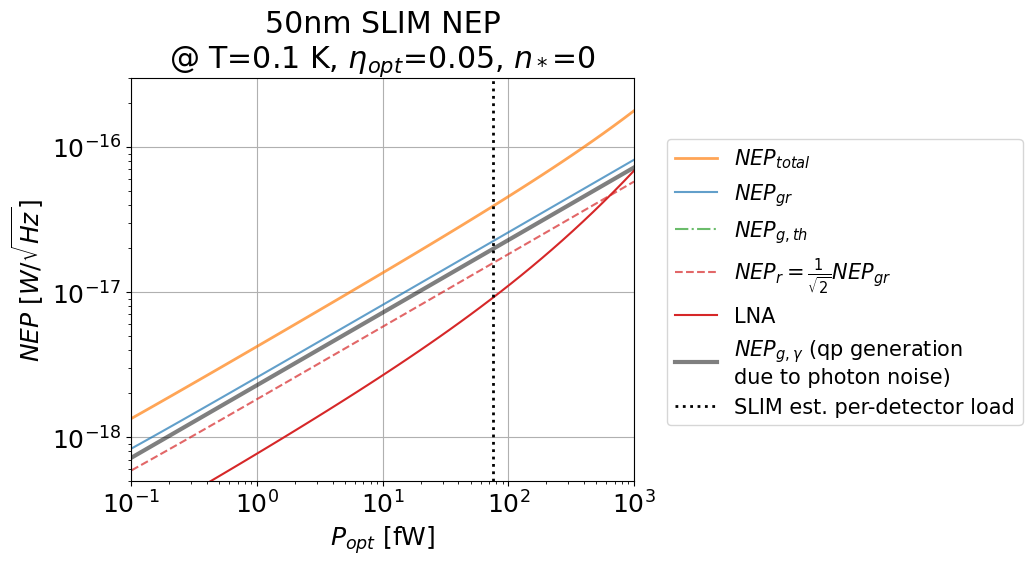

In [12]:
# res_params=res_params_50nm, Prange=np.logspace(-16, -12, 50), 
#                            eta_opt=0.05, n_star=0, T=0.15,
#                            nu_opt=180e9, Tn_LNA=6, ymin=2e-19, ymax=3e-16, ax_title=''
n_star = 0
eta_opt = 0.05
T=0.15
ax_title='50nm SLIM NEP\n@ T=%.1f K, $\\eta_{opt}$=%.2f, $n_*$=%d'%(T, eta_opt, n_star)
compute_NEP_quantities(res_params=copy.deepcopy(res_params_50nm), eta_opt=eta_opt, n_star=n_star,
                      T=T, ax_title=ax_title)